In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import linregress

In [2]:
output_dir = Path.cwd().parent / "reports" / "charts"
output_dir.mkdir(parents=True, exist_ok=True)

output_dir

WindowsPath('c:/Users/Manas Srivastava/Documents/MutualFundAnalytics/reports/charts')

In [3]:
nav = pd.read_csv(
    "../data/processed/clean_nav_history.csv",
    parse_dates=["date"]
)

performance = pd.read_csv(
    "../data/processed/clean_scheme_performance.csv"
)

transactions = pd.read_csv(
    "../data/processed/clean_investor_transactions.csv",
    parse_dates=["transaction_date"]
)

holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

In [4]:
nav.head()
transactions.head()
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [5]:
nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [6]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [7]:
var_report = (
    nav.groupby("amfi_code")["daily_return"]
       .quantile(0.05)
       .reset_index()
)

var_report.columns = [
    "amfi_code",
    "VaR_95"
]

var_report.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [8]:
def calculate_cvar(x):

    var = np.percentile(x.dropna(),5)

    return x[x<=var].mean()

In [9]:
cvar = (
    nav.groupby("amfi_code")["daily_return"]
       .apply(calculate_cvar)
       .reset_index()
)

cvar.columns=[
    "amfi_code",
    "CVaR"
]

cvar.head()

,amfi_code,CVaR
0,100016,-0.018060
1,100025,-0.004994
2,100033,-0.023456
3,101206,-0.017439
4,101207,-0.032459


In [10]:
var_report = var_report.merge(
    cvar,
    on="amfi_code"
)

var_report.head()

,amfi_code,VaR_95,CVaR
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [11]:
var_report.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

In [12]:
var_report.describe()

,amfi_code,VaR_95,CVaR
count,40.000000,40.000000,40.000000
mean,120247.000000,-0.014711,-0.018580
std,14534.998667,0.006821,0.008476
min,100016.000000,-0.026859,-0.032459
25%,118632.750000,-0.018394,-0.023133
50%,119551.500000,-0.014376,-0.018185
75%,120842.250000,-0.013247,-0.016572
max,149324.000000,-0.000222,-0.000373


In [13]:
rf_daily = 0.065 / 252

In [14]:
selected_funds = [
    119551,
    120503,
    118632,
    119092,
    120841
]

In [15]:
rolling_data = nav[
    nav["amfi_code"].isin(selected_funds)
].copy()

In [16]:
rolling_data["amfi_code"].unique()

array([118632, 119092, 119551, 120503, 120841])

In [17]:
rolling_data["rolling_mean"] = (
    rolling_data
    .groupby("amfi_code")["daily_return"]
    .transform(
        lambda x: x.rolling(90).mean()
    )
)

rolling_data["rolling_std"] = (
    rolling_data
    .groupby("amfi_code")["daily_return"]
    .transform(
        lambda x: x.rolling(90).std()
    )
)

In [18]:
rolling_data["rolling_sharpe"] = (
    (rolling_data["rolling_mean"] - rf_daily)
    /
    rolling_data["rolling_std"]
) * np.sqrt(252)

In [19]:
rolling_data.head()

,amfi_code,date,nav,daily_return,rolling_mean,rolling_std,rolling_sharpe
10350,118632,2022-01-03,42.8339,NaN,NaN,NaN,NaN
10351,118632,2022-01-04,42.8033,-0.000714,NaN,NaN,NaN
10352,118632,2022-01-05,43.0564,0.005913,NaN,NaN,NaN
10353,118632,2022-01-06,43.2088,0.003540,NaN,NaN,NaN
10354,118632,2022-01-07,42.9585,-0.005793,NaN,NaN,NaN


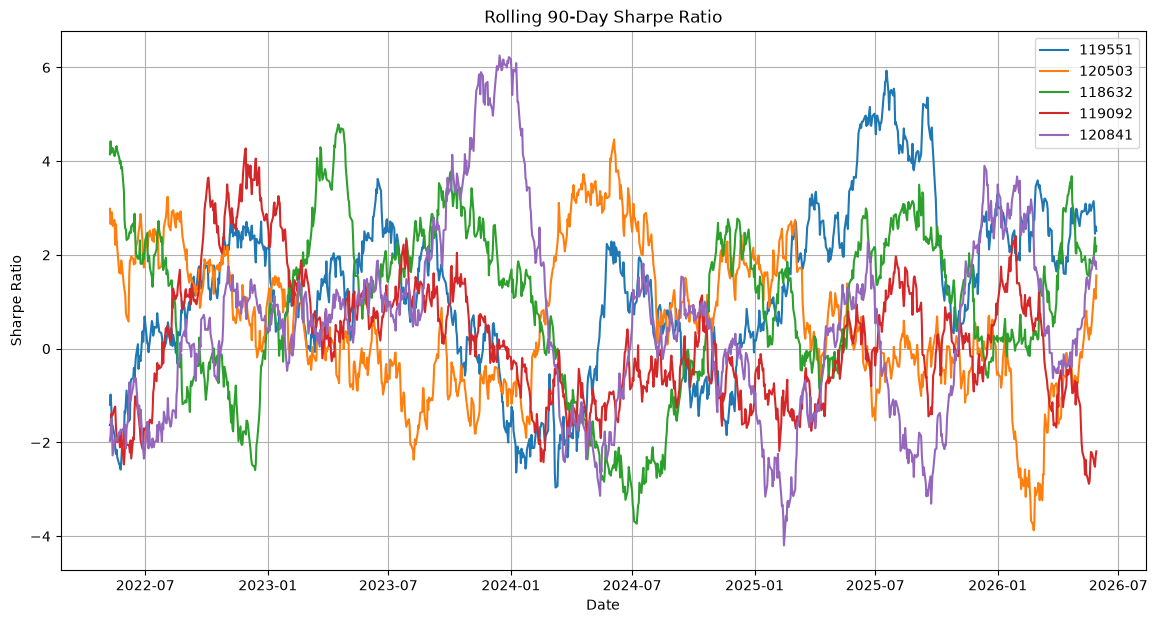

In [20]:
plt.figure(figsize=(14,7))

for fund in selected_funds:

    temp = rolling_data[
        rolling_data["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")

plt.xlabel("Date")

plt.ylabel("Sharpe Ratio")

plt.legend()

plt.grid(True)

In [21]:
plt.savefig(
    output_dir / "rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [22]:
first_txn = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_txn.rename(
    columns={"transaction_date":"first_transaction"},
    inplace=True
)

first_txn.head()

,investor_id,first_transaction
0,INV000001,2024-11-04
1,INV000002,2024-03-29
2,INV000003,2024-07-16
3,INV000004,2024-03-16
4,INV000005,2024-04-27


In [23]:
first_txn["cohort_year"] = (
    first_txn["first_transaction"].dt.year
)

first_txn.head()

,investor_id,first_transaction,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [24]:
transactions = transactions.merge(
    first_txn[
        ["investor_id","cohort_year"]
    ],
    on="investor_id",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [25]:
sip_txn = transactions[
    transactions["transaction_type"]=="SIP"
]

In [26]:
avg_sip = (
    sip_txn
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index()
)

avg_sip.rename(
    columns={"amount_inr":"avg_sip_amount"},
    inplace=True
)

avg_sip

,cohort_year,avg_sip_amount
0,2024,10996.885825
1,2025,13505.209581


In [27]:
total_investment = (
    transactions
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index()
)

total_investment.rename(
    columns={"amount_inr":"total_invested"},
    inplace=True
)

total_investment

,cohort_year,total_invested
0,2024,3491125187
1,2025,30455243


In [28]:
top_fund = (
    transactions
    .groupby(
        ["cohort_year","amfi_code"]
    )
    .size()
    .reset_index(name="count")
)

In [29]:
top_fund = (
    top_fund
    .sort_values(
        ["cohort_year","count"],
        ascending=[True,False]
    )
    .drop_duplicates("cohort_year")
)

top_fund.head()

,cohort_year,amfi_code,count
35,2024,148568,874
62,2025,119599,12


In [30]:
cohort_report = (
    avg_sip
    .merge(
        total_investment,
        on="cohort_year"
    )
    .merge(
        top_fund[
            ["cohort_year","amfi_code"]
        ],
        on="cohort_year"
    )
)

cohort_report

,cohort_year,avg_sip_amount,total_invested,amfi_code
0,2024,10996.885825,3491125187,148568
1,2025,13505.209581,30455243,119599


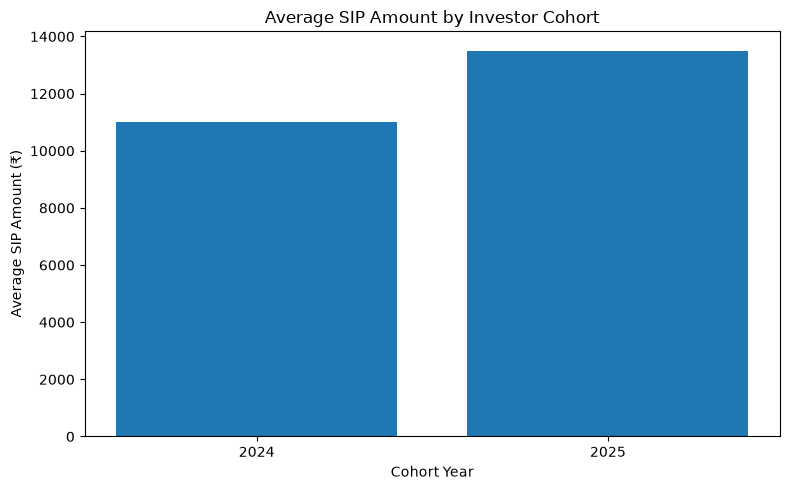

In [32]:
plt.figure(figsize=(8,5))

plt.bar(
    cohort_report["cohort_year"].astype(str),
    cohort_report["avg_sip_amount"]
)

plt.title("Average SIP Amount by Investor Cohort")
plt.xlabel("Cohort Year")
plt.ylabel("Average SIP Amount (₹)")

plt.tight_layout()

plt.savefig(
    output_dir / "cohort_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
sip = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

In [34]:
sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

In [35]:
sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
       .diff()
       .dt.days
)

In [36]:
sip.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0
12652,INV000003,2024-07-16,101207,SIP,2676,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,NaN
27622,INV000003,2025-03-11,149322,SIP,15185,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,238.0
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0


In [37]:
sip_count = (
    sip.groupby("investor_id")
       .size()
       .reset_index(name="num_sip_transactions")
)

sip_count.head()

,investor_id,num_sip_transactions
0,INV000001,2
1,INV000002,3
2,INV000003,2
3,INV000004,6
4,INV000005,3


In [38]:
eligible = sip_count[
    sip_count["num_sip_transactions"] >= 6
]

eligible.head()

,investor_id,num_sip_transactions
3,INV000004,6
7,INV000008,6
9,INV000010,6
10,INV000011,7
11,INV000012,8


In [39]:
avg_gap = (
    sip.groupby("investor_id")["gap_days"]
       .mean()
       .reset_index()
)

avg_gap.rename(
    columns={"gap_days": "avg_gap_days"},
    inplace=True
)

avg_gap.head()

,investor_id,avg_gap_days
0,INV000001,76.0
1,INV000002,207.0
2,INV000003,238.0
3,INV000004,85.4
4,INV000005,14.0


In [40]:
continuity = eligible.merge(
    avg_gap,
    on="investor_id"
)

continuity.head()

,investor_id,num_sip_transactions,avg_gap_days
0,INV000004,6,85.400000
1,INV000008,6,70.400000
2,INV000010,6,64.800000
3,INV000011,7,40.166667
4,INV000012,8,57.000000


In [41]:
continuity["risk_status"] = np.where(
    continuity["avg_gap_days"] > 35,
    "At Risk",
    "Healthy"
)

In [42]:
continuity.head()

,investor_id,num_sip_transactions,avg_gap_days,risk_status
0,INV000004,6,85.400000,At Risk
1,INV000008,6,70.400000,At Risk
2,INV000010,6,64.800000,At Risk
3,INV000011,7,40.166667,At Risk
4,INV000012,8,57.000000,At Risk


In [43]:
continuity["risk_status"].value_counts()

risk_status
At Risk    1332
Healthy      30
Name: count, dtype: int64

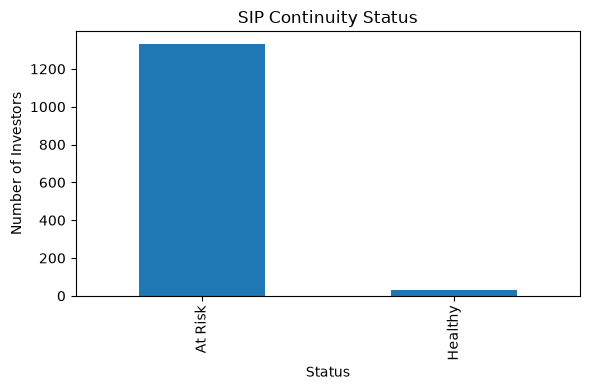

In [44]:
plt.figure(figsize=(6,4))

continuity["risk_status"].value_counts().plot(kind="bar")

plt.title("SIP Continuity Status")
plt.xlabel("Status")
plt.ylabel("Number of Investors")

plt.tight_layout()

plt.savefig(
    output_dir / "sip_continuity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
continuity.to_csv(
    "../reports/sip_continuity_report.csv",
    index=False
)

In [46]:
performance.columns.tolist()

['amfi_code',
 'scheme_name',
 'fund_house',
 'category',
 'plan',
 'return_1yr_pct',
 'return_3yr_pct',
 'return_5yr_pct',
 'benchmark_3yr_pct',
 'alpha',
 'beta',
 'sharpe_ratio',
 'sortino_ratio',
 'std_dev_ann_pct',
 'max_drawdown_pct',
 'aum_crore',
 'expense_ratio_pct',
 'morningstar_rating',
 'risk_grade']

In [47]:
performance["risk_grade"].unique()

<StringArray>
['Moderate', 'Very High', 'Low', 'High', 'Moderately High']
Length: 5, dtype: str

In [48]:
holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [49]:
holdings["weight"] = holdings["weight_pct"] / 100

In [50]:
hhi = (
    holdings
    .groupby("amfi_code")["weight"]
    .apply(lambda x: (x**2).sum())
    .reset_index(name="HHI")
)

In [51]:
hhi = hhi.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [52]:
hhi = hhi.sort_values("HHI", ascending=False)

hhi.head(10)

,amfi_code,HHI,scheme_name
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth


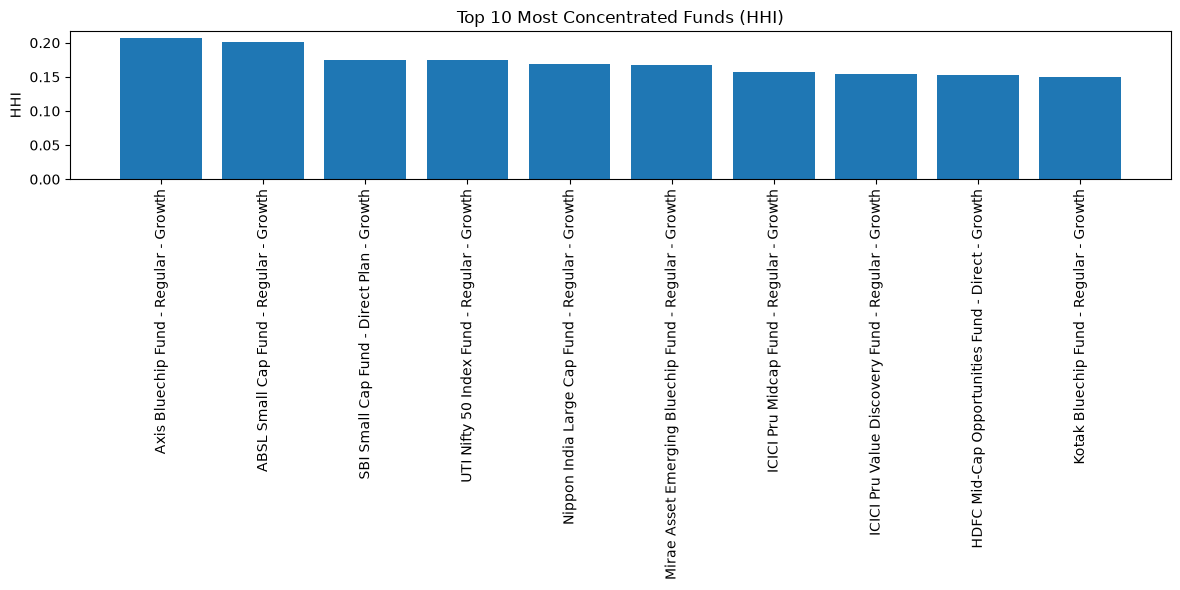

In [53]:
plt.figure(figsize=(12,6))

top10 = hhi.head(10)

plt.bar(
    top10["scheme_name"],
    top10["HHI"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Most Concentrated Funds (HHI)")
plt.ylabel("HHI")

plt.tight_layout()

plt.savefig(
    output_dir / "sector_hhi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [54]:
hhi.to_csv(
    "../reports/sector_hhi.csv",
    index=False
)

## Insight 1: Downside Risk Analysis (VaR & CVaR)

The Historical Value at Risk (VaR) and Conditional Value at Risk (CVaR) analysis showed that funds with higher return volatility also exhibited larger downside risk. Funds with more negative VaR values are expected to experience greater losses during adverse market conditions, while CVaR highlights the average loss during the worst-performing days. These metrics help investors understand tail risk beyond average returns.

## Insight 2: Rolling 90-Day Sharpe Ratio

The rolling 90-day Sharpe Ratio revealed that risk-adjusted performance varies over time. Some funds consistently maintained higher Sharpe Ratios, indicating better returns for each unit of risk, while others experienced significant fluctuations during volatile market periods. Investors seeking stable performance should consider funds with consistently positive rolling Sharpe Ratios.

## Insight 3: Investor Cohort Behaviour

Investor cohort analysis showed differences in investment behaviour across entry years. Recent cohorts demonstrated higher average SIP contributions, whereas earlier cohorts contributed larger cumulative investment amounts due to longer investment durations. The analysis also identified the most preferred mutual funds within each cohort.

## Insight 4: SIP Continuity Analysis

By measuring the average interval between SIP transactions, investors with average gaps greater than 35 days were identified as 'At Risk'. Most investors maintained regular SIP schedules, while a smaller group displayed irregular investment behaviour, providing an opportunity for targeted customer engagement and retention strategies.

## Insight 5: Portfolio Diversification Using HHI

The Herfindahl-Hirschman Index (HHI) measured portfolio concentration across equity funds. Funds with higher HHI values were more concentrated in a few holdings, potentially increasing concentration risk. Lower HHI values indicated better diversification, which generally reduces portfolio-specific risk.